# Các nội dung chính
1. Mục tiêu:
*   Nắm được các bước cơ bản trong khâu tiền xử lí dữ liệu.


2. Dữ liệu:
* Dữ liệu bất động sản - *Bengaluru_House_Data*
> Gồm các trường dữ liệu: location, size, total_sqft, price, ...


> Link Kaggle: https://www.kaggle.com/amitabhajoy/bengaluru-house-price-data




3. Yêu cầu:
* Sử dụng các công cụ (Pandas, Seaborn, ...) để thực hiện xem xét, đánh giá đặc điểm của dữ liệu, từ đó đưa ra phương án tiền xử lí dữ liệu (làm sạch, trích xuất thông tin ban đầu, ...)




# Nội dung thực hành

In [ ]:
#Nếu chạy trên Google Colab thì cần kết nối với máy chủ trước
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Chuẩn bị các thư viện cần thiết

In [ ]:
import numpy as np #Làm việc với các dữ liệu mảng nhiều chiều
import pandas as pd #Giúp làm việc với các dữ liệu dạng bảng
import matplotlib.pyplot as plt #Thư viện hỗ trợ trực quan hóa dữ liệu
import seaborn as sns #Thư viện giúp trực quan hóa dữ liệu, được xây trên matplotlib

### **Load dữ liệu từ file đã tải về**

**1. Đọc dữ liệu bằng pandas, dạng dataframe**

In [ ]:
path = "/content/drive/MyDrive/TA_AI_highschool/Bangalore_House_Price_data/Bengaluru_House_Data.csv"  # Đường dẫn đến file data csv
df_raw = pd.read_csv(path)  # Sử dụng thư viện pandas để đọc thông tin từ file data
df_raw.shape  #In ra thông tin kích thước của data

(13320, 9)

**2. Review 5 sample đầu tiên**

In [ ]:
df_raw.head() # return DataFrame

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


**Giải thích ý nghĩa các trường dữ liệu**
1. area_type: loại area - loại diện tích bất động sản.
2. availability: Tình trạng sẵn có của bất động sản.
3. location: Vị trí của bất động sản trong Bengaluru.
4. size: BHK - x Bedroom, Hall, Kitchen hoặc số lượng bedroom.
5. society: tên khu dân cư hoặc khu đô thị.
6. total_sqft: tổng diện tích của bất động sản, tính bằng feet vuông.
7. bath: số lượng phòng tắm.
8. balcony: số lượng ban công.
9. price: giá bất động sản.

**3. Review 5 sample cuối cùng**

In [ ]:
df_raw.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


### **Exploratory Data Analysis (EDA)**

In [ ]:
df = df_raw.copy() #Tạo bản sao để thực hiện EDA

**1. Thông tin cơ bản về dữ liệu, tên trường, số giá trị non-null của từng trường, kiểu dữ liệu của từng trường. Ở đây kiểu dữ liệu object lưu trữ dữ liệu chuỗi.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


**2. Thống kê 1 số thuộc tính cơ bản của dữ liệu, bao gồm count, mean, std, min, max, quartile**




Ở đây chỉ xét các cột có dữ liệu kiểu số.

- count: số lượng giá trị trong cột không bị thiếu.
- mean: giá trị trung bình của mỗi cột.
- std: độ lệch chuẩn, đo lường mức độ phân tán của các giá trị so với mean.
- min: giá trị nhỏ nhất của mỗi cột.

- 25% - Quartile 1: Giá trị tại điểm phần tư đầu tiên - 25% dữ liệu có giá trị <= giá trị này.
- 50% - Quartile 2: Giá trị trung vị - 50% dữ liệu có giá trị <= giá trị này.
- 75% - Quartile 3: Giá trị tại điểm phần tư thứ ba - 75% dữ liệu có giá trị <= giá trị này.
- max: giá trị lớn nhất của mỗi cột.

In [ ]:
df.describe() # Thực hiện thống kê

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


**3. Thống kê các giá trị duy nhất của từng trường và số lần xuất hiện của chúng**

In [ ]:
# Viết hàm để in ra số lượng các giá trị có trong từng cột

def value_count(df):
  for var in df.columns:  # duyệt từng cột
    print(df[var].value_counts()) # in ra các giá trị và số lượng của chúng có trong cột
    print("--------------------------------")

value_count(df)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
--------------------------------
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
--------------------------------
location
Whitefield                        540
Sarjapur  Road                    399
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64
-----------

**4. Xem xét tương quan về giá trị của các cặp trường số**

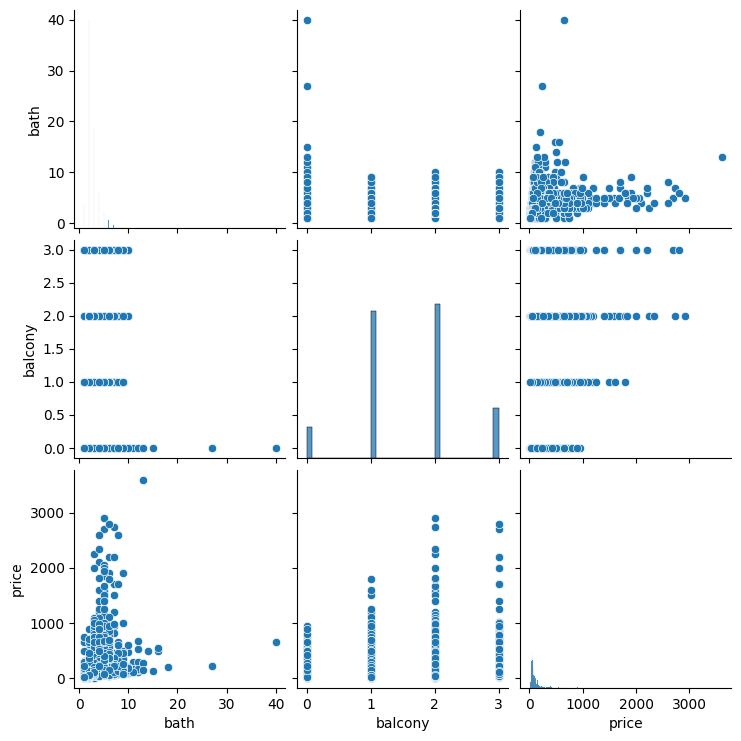

In [ ]:
sns.pairplot(df)  # Tạo ra biểu đồ phân tán cho mỗi cặp biến số khác nhau. Nếu mỗi cặp cùng biến số thì đó sẽ là biểu đồ phân bố.

<Axes: >

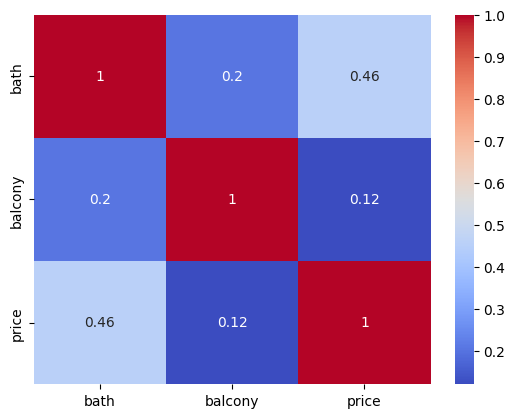

In [ ]:
num_vars = ["bath", "balcony", "price"]
sns.heatmap(df[num_vars].corr(),cmap="coolwarm", annot=True)  #In ra biểu đồ cho thấy sự tương quan giữa các biến số.

### **Chuẩn bị dữ liệu để huấn luyện mô hình**

#### **Xử lí các giá trị Null/ Nan**

**1. Thống kê tỉ lệ giá trị null của từng thuộc tính**

In [ ]:
df.isnull().mean()*100  # Tỷ lệ giá trị null của từng thuộc tính

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

**2. Loại đi trường society vì tỉ lệ null cao (41%)**

In [ ]:
df2 = df.drop('society', axis='columns')  # Drop cột society
df2.shape

(13320, 8)

**3. Thay thế giá trị null trong trường balcony bằng giá trị trung bình của các giá trị not null**

In [ ]:
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean()) #Thay các giá trị NaN bằng mean của cột balcony
df2.isnull().sum()

area_type        0
availability     0
location         1
size            16
total_sqft       0
bath            73
balcony          0
price            0
dtype: int64

**4. Xóa đi các điểm dữ liệu (hàng) có giá trị nan (không có giá trị)**

In [ ]:
df3 = df2.dropna()
df3.shape

(13246, 8)

In [ ]:
df3.isnull().sum() #Thống kê lại xem đã xử lí hết các dữ liệu null hay chưa?

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

#### **Xử lí các trường thuộc tính**

In [ ]:
#Cho phép in ra toàn bộ các giá trị output có thể của câu lệnh mà không bị cắt
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

**1. Converting 'total_sqft' feature in numeric (float)**

In [ ]:
# Xem xét trường total_sqft
df3['total_sqft'].value_counts()

total_sqft
1200                 843
1100                 221
1500                 204
2400                 195
600                  180
1000                 172
1350                 132
1050                 123
1300                 117
1250                 114
900                  112
1400                 108
1800                 104
1150                 101
1600                 100
1140                  91
2000                  82
1450                  70
1650                  69
800                   67
3000                  66
1075                  66
1020                  63
2500                  62
1125                  60
1160                  60
1550                  60
950                   59
1700                  58
1180                  58
1260                  57
1255                  56
1080                  55
1220                  55
1070                  53
750                   52
700                   52
4000                  48
1175                  48
1225          

In [ ]:
#Xử lí các giá trị của trường total_sqft và lưu vào một biến tạm

total_sqft_float = [] #Biến tạm để lưu giá trị được xử lí
for str_val in df3['total_sqft']:
  try:
    total_sqft_float.append(float(str_val)) #ép kiểu từ string về float
  except: #Nếu không thể ép kiểu ngay lập tức, xét thêm trường hợp string như "2725 - 3250"
    try:
      temp = []
      temp = str_val.split('-')
      total_sqft_float.append((float(temp[0])+float(temp[-1]))/2) #lấy trung bình của số đầu và số cuối khi có gạch ngang
    except: # Các trường hợp còn lại
      total_sqft_float.append(np.nan) #Gia tri ngoai le se duoc dat thanh null

df4 = df3.reset_index(drop=True) #Đặt lại chỉ số tuần tự từ 0, loại bỏ chỉ số cũ

In [ ]:
# Thêm trường total_sqft_float:

df5 = df4.join(pd.DataFrame({'total_sqft_float':total_sqft_float}))
df5.head() #Quan sát kết quả sau khi xử lí

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0


In [ ]:
# Xem xét lại thông tin về các giá trị null
df5.isnull().sum()

area_type            0
availability         0
location             0
size                 0
total_sqft           0
bath                 0
balcony              0
price                0
total_sqft_float    46
dtype: int64

In [ ]:
# Loại bỏ các hàng có giá trị null
df6 = df5.dropna()
df6.shape

(13200, 9)

In [ ]:
# Xem lại thông tin của dataframe
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13245
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13200 non-null  object 
 1   availability      13200 non-null  object 
 2   location          13200 non-null  object 
 3   size              13200 non-null  object 
 4   total_sqft        13200 non-null  object 
 5   bath              13200 non-null  float64
 6   balcony           13200 non-null  float64
 7   price             13200 non-null  float64
 8   total_sqft_float  13200 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.0+ MB


**2. Làm việc với feature: size**

In [ ]:
# Quan sát sự phân bố giá trị của trường 'size' với value_counts
df6['size'].value_counts()

size
2 BHK         5192
3 BHK         4277
4 Bedroom      816
4 BHK          574
3 Bedroom      541
1 BHK          527
2 Bedroom      325
5 Bedroom      293
6 Bedroom      190
1 Bedroom      100
7 Bedroom       83
8 Bedroom       83
5 BHK           56
9 Bedroom       45
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            7
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [ ]:
#Chuyển thuộc tính số phòng từ dạng category về dạng numeric
size_int = []
for str_val in df6['size']:
  temp=[]
  temp = str_val.split(" ")
  try:
    size_int.append(int(temp[0]))#lấy số lượng ở đầu
  except:
    size_int.append(np.nan)
    print("Noise = ",str_val)

In [ ]:
#Đánh lại index cho các hàng theo dãy số tự nhiên liên tiếp
df6 = df6.reset_index(drop=True)

In [ ]:
# Thêm trường dữ liệu số phòng (bhk)
df7 = df6.join(pd.DataFrame({'bhk':size_int}))
df7.shape

(13200, 10)

In [ ]:
#In ra kết quả thực hiện các thao tác kể trên?
df7.tail()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
13195,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.000000,231.0,3453.0,5
13196,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,1.584376,400.0,3600.0,4
13197,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.000000,60.0,1141.0,2
13198,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,4689,4.0,1.000000,488.0,4689.0,4
13199,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,550,1.0,1.000000,17.0,550.0,1


**3. Phát hiện ngoại lệ (outlier) và loại bỏ**
* Dựa trên biểu đồ boxplot/ hoặc công cụ khác để phát hiện và loại bỏ các điểm ngoại lai:

<Axes: xlabel='total_sqft_float'>

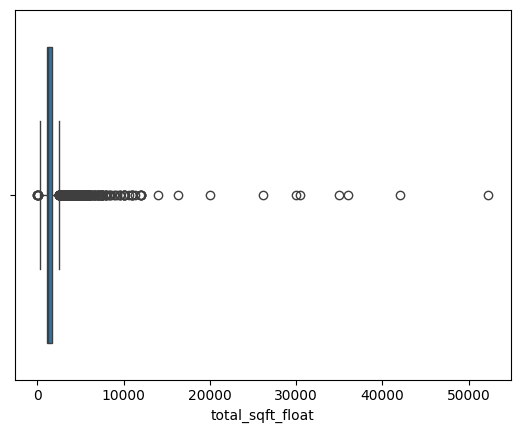

In [ ]:
# Xem xét trường diện tích:
sns.boxplot(x = df7['total_sqft_float'])

<Axes: xlabel='total_sqft_float'>

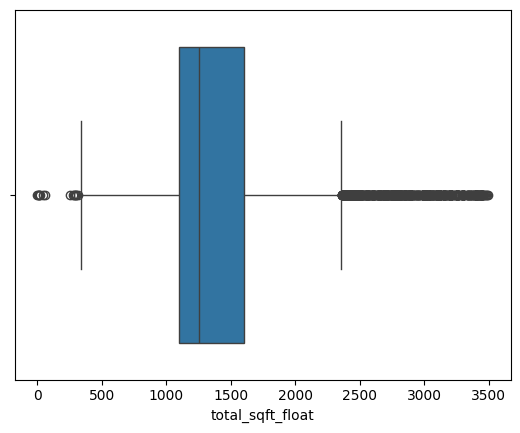

In [ ]:
# Chọn ngưỡng diện tích là 3500 để xem xét
df_temp7 = df7[df7['total_sqft_float'] < 3500]
sns.boxplot(x = df_temp7['total_sqft_float'])

In [ ]:
df7.describe()

,bath,balcony,price,total_sqft_float,bhk
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,2.691136,1.585598,112.276178,1555.302783,2.800833
std,1.338915,0.800128,149.175995,1237.323445,1.292843
min,1.000000,0.000000,8.000000,1.000000,1.000000
25%,2.000000,1.000000,50.000000,1100.000000,2.000000
50%,2.000000,2.000000,71.850000,1275.000000,3.000000
75%,3.000000,2.000000,120.000000,1672.000000,3.000000
max,40.000000,3.000000,3600.000000,52272.000000,43.000000


(10977, 10)

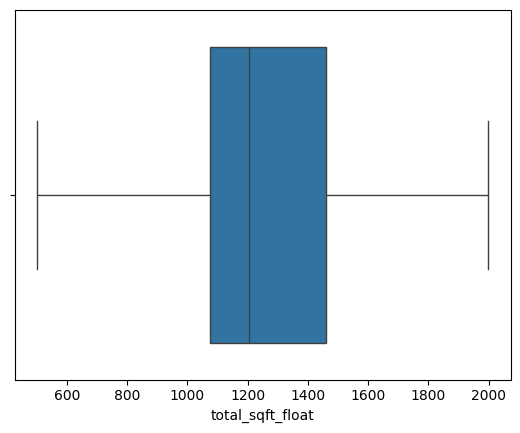

In [ ]:
# Loại bỏ đi các điểm dữ liệu có diện tích >= 2000 hoặc <= 500
# Q1 = 1100, Q2 = 1275, Q3 = 1672, IQR = Q3 - Q1
# (Q1 - 1.5 * IQR or Q3 + 1.5 * IQR)
df8 = df7[(df7['total_sqft_float'] > 500) & (df7['total_sqft_float'] <2000)]
sns.boxplot(x = df8['total_sqft_float'])
df8.shape

In [ ]:
# Tạo thêm trường dữ liệu price_per_sqft (giá/ diện tích feet vuông)
df8 = df8.reset_index(drop=True)
df8['price_per_sqft'] = df8['price']*100000 / df8['total_sqft_float']
df8.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0,2,3699.810606
1,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0,3,4305.555556
2,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0,3,6245.890861
3,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0,2,4250.000000
4,Super built-up Area,Ready To Move,Whitefield,2 BHK,1170,2.0,1.0,38.00,1170.0,2,3247.863248


In [ ]:
#Thông số về cột price_per_sqft
df8.price_per_sqft.describe()

count    10977.000000
mean      6168.807617
std       3646.940348
min       1166.666667
25%       4166.666667
50%       5179.856115
75%       6666.666667
max      76923.076923
Name: price_per_sqft, dtype: float64